# Final Project — PathBridger (IDM path) on AntMaze-Large

This notebook shows how to **run** the core of the PathBridger project end-to-end on the
`antmaze-large-navigate-v0` task, using only the minimal pieces needed for the
**Inverse-Dynamics-Model (IDM)** rollout path. The actor / critic training machinery is
intentionally left out — we only keep the **dynamics agent** (subgoal predictor + forward
bridge planner + inverse dynamics head).

## What the method does

Given a current state $s_t$ and a far-away goal $g$, the agent reaches the goal by repeatedly:

1. **Subgoal prediction** — `infer_subgoal(s_t, g)` predicts a reachable intermediate
   endpoint $\hat{s}_{t+K}$ (here $K=25$). The subgoal net is a diagonal-Gaussian head
   trained on goal-conditioned future states.
2. **Forward-bridge planning** — `plan(s_t, \hat{s}_{t+K})` produces a smooth
   state trajectory $s_t = z_0, z_1, \dots, z_K = \hat{s}_{t+K}$ from a closed-form
   linear-SDE Gaussian *bridge* plus a learned endpoint-preserving residual correction.
3. **Inverse dynamics (IDM)** — for each consecutive pair $(z_i, z_{i+1})$ along the plan,
   the inverse-dynamics MLP `idm_net(z_i, z_{i+1})` predicts the action that moves the
   agent from $z_i$ to $z_{i+1}$. We execute the first `action_chunk_horizon = 5` actions,
   then re-plan from the new state.

So the full control loop is **subgoal → bridge trajectory → IDM actions → step → re-plan**.
No reward, no value function, and no separate policy network are needed at inference time.

## Notebook structure

1. Environment / import setup
2. **Hard-coded** AntMaze-Large config (matches the best trained checkpoint)
3. Build the env + offline dataset
4. **Short training demo** — train the dynamics agent for a few epochs (loss goes down)
5. Load the **best pre-trained checkpoint** (600 epochs)
6. **Evaluation** — IDM rollout success rate over the 5 eval tasks
7. **Render** an IDM rollout video and display it inline

## 1. Setup

We add the bundled `pb/` package directory to `sys.path` (it contains the minimal
`agents/`, `utils/`, `rollout/` modules copied from the PathBridger repo), configure a
headless MuJoCo backend (EGL) for rendering, and keep JAX from pre-allocating the whole GPU
so the notebook can share the device with other jobs.

In [1]:
import os
import sys
from pathlib import Path

# Headless rendering backend. Must be set before importing JAX / MuJoCo.
os.environ.setdefault("MUJOCO_GL", "egl")

# Make the bundled minimal PathBridger modules importable as top-level packages
# (`agents`, `utils`, `rollout`).
PROJECT_DIR = Path.cwd()
PB_DIR = PROJECT_DIR / "pb"
if str(PB_DIR) not in sys.path:
    sys.path.insert(0, str(PB_DIR))

import jax
import numpy as np

print("jax backend:", jax.default_backend())
print("jax devices:", jax.devices())
print("project dir:", PROJECT_DIR)

jax backend: gpu
jax devices: [CudaDevice(id=0)]
project dir: /home/offrl/Embodied_AI


## 2. Hard-coded config

The dynamics-agent configuration below is **hard-coded** and is identical to the resolved
config of the best AntMaze-Large run (`checkpoint/flags.json`, 600 epochs, IDM success
≈ 0.87). Key choices:

- `dynamics_N = 25` — bridge horizon $K$ (also `subgoal_steps`).
- `subgoal_distribution = diag_gaussian` — stochastic subgoal head.
- `planner_type = forward_bridge_residual` — closed-form bridge + learned residual.
- `subgoal_goal_representation = phi`, `phi_goal_obs_indices = [0, 1]` — the subgoal net is
  conditioned only on the maze $(x, y)$ goal coordinates.
- `subgoal_value_alpha = 0.0` — the critic value bonus is **disabled**, so the dynamics agent
  trains and runs **standalone** (no critic / actor needed for the IDM path).

We start from the code defaults (`get_dynamics_config()`) and overlay these values, so any
key not listed here keeps its in-code default.

In [2]:
from agents.dynamics import get_dynamics_config, DynamicsAgent

ENV_NAME = "antmaze-large-navigate-v0"
SEED = 0
ACTION_CHUNK_HORIZON = 5  # env steps executed per re-plan (<= dynamics_N)

# Hard-coded overrides for the best AntMaze-Large IDM run (== checkpoint/flags.json["dynamics"]).
DYNAMICS_OVERRIDES = {
    "algorithm": "trl",
    "critic_type": "trl",
    "env_name": ENV_NAME,
    "discount": 0.995,
    "lr": 3e-4,
    "batch_size": 1024,
    "layer_norm": True,
    # --- linear-SDE forward bridge ---
    "dynamics_N": 25,
    "dynamics_beta_min": 0.1,
    "dynamics_beta_max": 20.0,
    "dynamics_lambda": 1.0,
    "bridge_gamma_inv": 0.0,
    "dynamics_model_type": "exact_residual",
    "planner_type": "forward_bridge_residual",
    "forward_bridge_mode": "mean",
    "forward_bridge_use_path_loss": True,
    "forward_bridge_path_loss_horizon": 5,
    "residual_model_hidden_dims": (512, 512, 512),
    "residual_target_mode": "displacement",
    "theta_schedule": "prefix_progress",
    "theta_total": 1.0,
    "progress_alpha": 0.8,
    "time_embed_dim": 64,
    "use_time_embedding": True,
    "rollout_horizon": 5,
    # --- subgoal head ---
    "subgoal_steps": 25,
    "subgoal_distribution": "diag_gaussian",
    "subgoal_stochastic_loss": "nll",
    "subgoal_target_mode": "absolute",
    "subgoal_goal_representation": "phi",
    "phi_goal_obs_indices": (0, 1),
    "subgoal_hidden_dims": (512, 512, 512),
    "subgoal_log_std_min": -5.0,
    "subgoal_log_std_max": 1.0,
    "subgoal_num_samples": 1,
    "subgoal_temperature": 1.0,
    "clip_path_to_goal": True,
    # --- value-gap weighting (critic disabled -> no-op at alpha=0) ---
    "subgoal_value_alpha": 0.0,
    "subgoal_value_style": "exponential",
    "subgoal_value_gap_scale": 10.0,
    "subgoal_value_weight_max": 5.0,
    "subgoal_value_bonus_type": "transitive_product",
    "subgoal_value_goal_representation": "full",
    "subgoal_value_hidden_dims": (512, 512, 512),
    "subgoal_value_layer_norm": True,
    # --- inverse dynamics head ---
    "idm_hidden_dims": (512, 512, 512),
    "idm_loss_weight": 1.0,
    # --- misc ---
    "state_normalization": False,
    "max_goal_steps": 1000,
    "max_goal_steps_from_env": False,
}

def build_dynamics_config():
    cfg = get_dynamics_config()
    for k, v in DYNAMICS_OVERRIDES.items():
        cfg[k] = v
    return cfg

dynamics_config = build_dynamics_config()
print("dynamics_N        =", dynamics_config["dynamics_N"])
print("subgoal_distribution =", dynamics_config["subgoal_distribution"])
print("planner_type      =", dynamics_config["planner_type"])
print("subgoal_value_alpha  =", dynamics_config["subgoal_value_alpha"], "(critic disabled)")

dynamics_N        = 25
subgoal_distribution = diag_gaussian
planner_type      = forward_bridge_residual
subgoal_value_alpha  = 0.0 (critic disabled)


## 3. Build the environment and offline dataset

`make_env_and_datasets` downloads (or loads from cache) the OGBench `antmaze-large-navigate-v0`
offline dataset and creates the rendering-enabled environment. `PathHGCDataset` wraps the raw
transitions and, for each sampled start $t$, yields a same-episode trajectory segment
$s_t, s_{t+1}, \dots, s_{t+K}$ used for the bridge / subgoal / IDM losses.

In [3]:
import jax.numpy as jnp
from utils.datasets import Dataset, PathHGCDataset
from utils.env_utils import make_env_and_datasets

env, train_plain, _ = make_env_and_datasets(
    ENV_NAME,
    frame_stack=None,
    render_mode="rgb_array",
)

obs_dim = int(np.prod(env.observation_space.shape))
action_dim = int(np.prod(env.action_space.shape))
num_tasks = int(getattr(env.unwrapped, "num_tasks", 5))
print(f"obs_dim={obs_dim}  action_dim={action_dim}  num_tasks={num_tasks}")

dynamics_dataset = PathHGCDataset(Dataset.create(**train_plain), dynamics_config)
print("dataset transitions:", dynamics_dataset.size)

# A single example batch is enough to initialize the network shapes.
ex_batch = dynamics_dataset.sample(8)
print("batch keys:", sorted(ex_batch.keys()))
print("trajectory_segment shape:", np.asarray(ex_batch["trajectory_segment"]).shape)

obs_dim=29  action_dim=8  num_tasks=5
dataset transitions: 1001000
batch keys: ['actions', 'high_actor_goal_idxs', 'high_actor_goals', 'high_actor_target_idxs', 'high_actor_targets', 'low_actor_goals', 'masks', 'next_observations', 'observations', 'rewards', 'terminals', 'trajectory_indices', 'trajectory_segment', 'trajectory_start_indices', 'trajectory_terminal_indices', 'valids', 'value_goals']
trajectory_segment shape: (8, 26, 29)


## 4. Short training demo

To show the training path runs, we create a fresh `DynamicsAgent` and update it for a small
number of steps. We pass `critic_value_params=None`, so the value-gap weighting degenerates to
weight 1 and the agent trains **fully standalone** (subgoal NLL + forward-bridge path loss +
IDM regression). This is a *demo* — the full 0.87-success model was trained for 600 epochs;
here we only run enough steps to see the loss decrease.

In [4]:
import time

DEMO_STEPS = 60
DEMO_BATCH = 256

# Fresh agent initialized from an example batch (shape-only).
ex = dynamics_dataset.sample(DEMO_BATCH)
demo_agent = DynamicsAgent.create(
    SEED,
    jnp.asarray(ex["observations"], dtype=jnp.float32),
    dynamics_config,
    ex_actions=jnp.asarray(ex["actions"], dtype=jnp.float32),
)

history = []
t0 = time.time()
for step in range(1, DEMO_STEPS + 1):
    batch = dynamics_dataset.sample(DEMO_BATCH)
    demo_agent, info = demo_agent.update(batch, critic_value_params=None)
    if step == 1 or step % 10 == 0:
        rec = {
            "step": step,
            "loss": float(info["phase1/loss"]),
            "subgoal": float(info["phase1/loss_subgoal"]),
            "idm": float(info["phase1/loss_idm"]),
            "path": float(info["phase1/loss_path_step"]),
        }
        history.append(rec)
        print(f"step {step:3d} | total {rec['loss']:.4f} | subgoal {rec['subgoal']:.4f} "
              f"| idm {rec['idm']:.4f} | path {rec['path']:.4f}")
print(f"\n{DEMO_STEPS} steps in {time.time() - t0:.1f}s (first step includes JIT compile)")

2026-06-22 00:58:55.111955: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 11 configs for gemm_fusion_dot on a single thread.


2026-06-22 00:58:56.681219: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 13 configs for gemm_fusion_dot on a single thread.


2026-06-22 00:58:58.876079: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 13 configs for gemm_fusion_dot on a single thread.


2026-06-22 00:59:00.517577: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 3 configs for gemm_fusion_dot.3 on a single thread.


2026-06-22 00:59:00.990703: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 5 configs for gemm_fusion_dot.3 on a single thread.


2026-06-22 00:59:01.663774: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 3 configs for gemm_fusion_dot.3 on a single thread.


2026-06-22 00:59:01.990005: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 3 configs for gemm_fusion_dot.3 on a single thread.


2026-06-22 00:59:02.258488: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:02.258508: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 33 configs for gemm_fusion_dot.3 on a single thread.


2026-06-22 00:59:06.242491: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:06.242543: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:06.242566: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:06.242784: W external/xla/xla/service/gpu/au

step   1 | total 11171.8457 | subgoal 11125.0742 | idm 2.8336 | path 18.9923
step  10 | total 166.1469 | subgoal 121.3428 | idm 0.5350 | path 19.7892
step  20 | total 123.4728 | subgoal 84.9566 | idm 0.3214 | path 17.1007
step  30 | total 118.5173 | subgoal 78.0339 | idm 0.2756 | path 18.2539
step  40 | total 113.5967 | subgoal 73.2751 | idm 0.2421 | path 18.3748
step  50 | total 108.4420 | subgoal 71.0087 | idm 0.2317 | path 17.0277
step  60 | total 107.7839 | subgoal 69.3860 | idm 0.2172 | path 17.9556

60 steps in 28.4s (first step includes JIT compile)


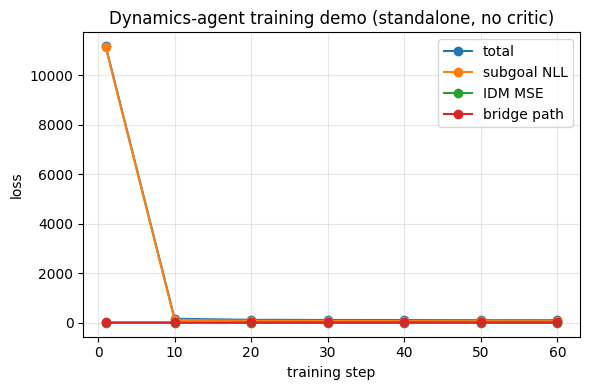

In [5]:
import matplotlib.pyplot as plt

steps = [h["step"] for h in history]
fig, ax = plt.subplots(figsize=(6, 4))
for key, label in [("loss", "total"), ("subgoal", "subgoal NLL"),
                   ("idm", "IDM MSE"), ("path", "bridge path")]:
    ax.plot(steps, [h[key] for h in history], marker="o", label=label)
ax.set_xlabel("training step")
ax.set_ylabel("loss")
ax.set_title("Dynamics-agent training demo (standalone, no critic)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Load the best pre-trained checkpoint

The 60-step demo above is far from converged. For evaluation and rendering we load the
**fully-trained** dynamics checkpoint (`checkpoint/dynamics/params_600.pkl`, 600 epochs).
We rebuild a `DynamicsAgent` with the same hard-coded config and deserialize the saved
parameters into it.

In [6]:
from utils.run_io import load_checkpoint_pkl

CKPT_PATH = PROJECT_DIR / "checkpoint" / "dynamics" / "params_600.pkl"
assert CKPT_PATH.is_file(), f"checkpoint not found: {CKPT_PATH}"

agent = DynamicsAgent.create(
    SEED,
    jnp.zeros((1, obs_dim), dtype=jnp.float32),
    dynamics_config,
    ex_actions=jnp.zeros((1, action_dim), dtype=jnp.float32),
)
agent = load_checkpoint_pkl(agent, CKPT_PATH)
print("loaded:", CKPT_PATH.name)
head_keys = list(agent.network.params.keys())
print("network heads:", head_keys)
# Flax ModuleDict may prefix keys with "modules_".
assert any("idm_net" in k for k in head_keys), "embedded idm_net required for the IDM path"

2026-06-22 00:59:34.512771: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:34.512790: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 33 configs for gemm_fusion_dot on a single thread.


2026-06-22 00:59:37.310013: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 4 configs for gemm_fusion_dot on a single thread.


2026-06-22 00:59:37.527738: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:37.527761: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 33 configs for gemm_fusion_dot on a single thread.


loaded: params_600.pkl
network heads: ['modules_path_residual_net', 'modules_subgoal_net', 'modules_idm_net']


## 6. IDM rollout

The function below implements the inference control loop described at the top. On each
re-plan it runs `infer_subgoal → plan → idm_net`, executes up to `ACTION_CHUNK_HORIZON`
actions in the real env, and repeats until the env reports success or the chunk budget runs
out. Success is decided **only** by the env's `info["success"]`. We reuse the project's shared
`run_chunked_episode` loop and the env state-sync helper.

In [7]:
from rollout.env import sync_env_state_from_obs_vector_aligned
from rollout.episode_runner import run_chunked_episode

ACTION_LOW = np.asarray(env.action_space.low, dtype=np.float32).reshape(-1)
ACTION_HIGH = np.asarray(env.action_space.high, dtype=np.float32).reshape(-1)


def idm_rollout(env, agent, task_id, max_chunks=200, record_rgb=False, seed=None):
    """Run one IDM rollout for an OGBench eval task. Returns (success, n_chunks, rgb_frames)."""
    reset_kw = dict(options=dict(task_id=int(task_id), render_goal=False))
    if seed is not None:
        reset_kw["seed"] = int(seed)
    ob, info = env.reset(**reset_kw)
    s0 = np.asarray(ob, dtype=np.float32).reshape(-1)
    s_g = np.asarray(info["goal"], dtype=np.float32).reshape(-1)
    cur = sync_env_state_from_obs_vector_aligned(env, s0, s_g)

    horizon = int(ACTION_CHUNK_HORIZON)

    def chunk_fn(obs, goal):
        s = jnp.asarray(obs, dtype=jnp.float32)
        g = jnp.asarray(goal, dtype=jnp.float32)
        hat = agent.infer_subgoal(s, g)                 # (1) subgoal endpoint
        traj = jax.device_get(agent.plan(s, hat)["trajectory"])  # (2) bridge states (K+1, D)
        actions = jax.device_get(                        # (3) inverse-dynamics actions
            agent._idm_actions_from_trajectories(
                jnp.asarray(traj[None], dtype=jnp.float32), horizon
            )
        )[0]
        return np.asarray(actions, dtype=np.float32)

    outcome = run_chunked_episode(
        env, cur, s_g,
        low=ACTION_LOW, high=ACTION_HIGH,
        max_chunks=int(max_chunks),
        sample_action_chunk=chunk_fn,
        record_rgb=bool(record_rgb),
    )
    return bool(outcome.ok_env), int(outcome.n_chunks), outcome.rgb_frames

# Smoke test on task 1 (this triggers JIT compilation of infer_subgoal / plan / idm_net).
ok, nchunks, _ = idm_rollout(env, agent, task_id=1, max_chunks=200, record_rgb=False)
print(f"task 1 smoke rollout: success={ok}  replans={nchunks}")

2026-06-22 00:59:42.613754: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:42.613783: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:42.613793: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1157] Compiling 70 configs for 3 fusions on a single thread.


2026-06-22 00:59:50.859239: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:50.859260: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 33 configs for gemm_fusion_dot.3 on a single thread.


2026-06-22 00:59:53.586291: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 2 configs for gemm_fusion_dot.3 on a single thread.
2026-06-22 00:59:53.697723: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-22 00:59:53.697746: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1154] Compiling 33 configs for gemm_fusion_dot.3 on a single thread.


task 1 smoke rollout: success=True  replans=126


### Evaluation: per-task success rate

Run several episodes for each of the 5 eval tasks and report the IDM success rate. (Episode
count is kept modest here so the notebook runs quickly; the paper-style number uses 50
episodes/task.)

In [8]:
EVAL_TASKS = [1, 2, 3, 4, 5]
EPISODES_PER_TASK = 10
EVAL_MAX_CHUNKS = 200

rows = []
overall_succ = []
for tid in EVAL_TASKS:
    succ = []
    for ep in range(EPISODES_PER_TASK):
        ok, _, _ = idm_rollout(
            env, agent, task_id=tid,
            max_chunks=EVAL_MAX_CHUNKS, record_rgb=False,
            seed=1000 * tid + ep,
        )
        succ.append(1.0 if ok else 0.0)
    rate = float(np.mean(succ))
    overall_succ.extend(succ)
    rows.append((tid, rate))
    print(f"task {tid}: success {rate:.2f}  ({int(sum(succ))}/{EPISODES_PER_TASK})")

print("-" * 32)
print(f"overall IDM success rate: {np.mean(overall_succ):.3f} "
      f"over {len(EVAL_TASKS)} tasks x {EPISODES_PER_TASK} episodes")

task 1: success 0.90  (9/10)


task 2: success 0.90  (9/10)


task 3: success 1.00  (10/10)


task 4: success 0.80  (8/10)


task 5: success 0.60  (6/10)
--------------------------------
overall IDM success rate: 0.840 over 5 tasks x 10 episodes


## 7. Render an IDM rollout video

Finally, we record the RGB frames of one IDM rollout and write them to an MP4, then display it
inline. The ant should navigate the large maze toward the goal using the
subgoal → bridge → IDM control loop.

In [9]:
from rollout.plot import write_rgb_array_mp4

RENDER_TASK = 1
RENDER_DIR = PROJECT_DIR / "renders"
RENDER_DIR.mkdir(exist_ok=True)
mp4_path = RENDER_DIR / f"idm_task{RENDER_TASK}.mp4"

ok, nchunks, frames = idm_rollout(
    env, agent, task_id=RENDER_TASK,
    max_chunks=EVAL_MAX_CHUNKS, record_rgb=True, seed=1000 * RENDER_TASK,
)
print(f"task {RENDER_TASK}: success={ok}  replans={nchunks}  frames={None if frames is None else frames.shape}")

assert frames is not None and frames.size > 0, "no RGB frames captured (check MUJOCO_GL)"
write_rgb_array_mp4(frames, mp4_path, fps=30.0)
print("wrote:", mp4_path)

task 1: success=True  replans=136  frames=(677, 200, 200, 3)
wrote: /home/offrl/Embodied_AI/renders/idm_task1.mp4


/home/offrl/miniconda3/envs/offrl/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


In [10]:
from IPython.display import Video

Video(str(mp4_path), embed=True, width=480)

## 8. Running other environments

This notebook hard-codes the **AntMaze-Large** config, but the same IDM path works on the other
OGBench environments the project was trained on. To switch environments you would:

1. **Change `ENV_NAME`** to the target task, e.g. `antmaze-medium-navigate-v0`,
   `cube-double-play-singletask-v0`, `cube-triple-play-singletask-v0`,
   `puzzle-3x3-play-singletask-v0`, or `puzzle-4x4-play-singletask-v0`.
2. **Use that env's matching config.** Each environment has its own resolved hyper-parameters
   (saved as `flags.json` / `config_used.yaml` next to its checkpoint in the original
   PathBridger `runs/` directory). The keys that typically change per environment are:
   - `subgoal_goal_representation` / `phi_goal_obs_indices` — AntMaze conditions the subgoal on
     just the `(x, y)` goal coordinates (`phi`, indices `(0, 1)`); the manipulation envs use the
     `full` observation as the goal.
   - `subgoal_value_gap_scale`, `subgoal_value_weight_max`, `dynamics_N` (`= K`) — tuned per env.
3. **Point `CKPT_PATH` at the matching trained checkpoint** (`params_<epoch>.pkl`).

Two environment families are handled automatically by the rollout helpers:

- **Maze navigation** (`antmaze-*-navigate`): the observation is `qpos || qvel`, so the env
  state can be re-synced from an observation vector (`sync_env_state_from_obs_vector_aligned`),
  and goals are 2-D maze coordinates.
- **Manipulation play** (`cube-*`, `puzzle-*`): observations are compact (non-`qpos||qvel`)
  vectors, so the rollout trusts the reset state and there is no maze navigator. `is_manipspace_env`
  selects this path; the subgoal → bridge → IDM control loop itself is unchanged.

No code changes are required beyond `ENV_NAME`, the config overrides, and the checkpoint path —
the dynamics agent, planner, and IDM head are environment-agnostic.

## Summary

- We built and ran the **IDM path** of PathBridger on `antmaze-large-navigate-v0` with a
  hard-coded config and only the minimal dynamics modules (no actor, no critic).
- A short training demo showed the standalone dynamics loss (subgoal NLL + bridge path + IDM
  MSE) decreasing.
- Loading the 600-epoch checkpoint, we evaluated the **subgoal → forward-bridge → inverse-dynamics**
  control loop over the 5 eval tasks and rendered a rollout video.

The full training pipeline (which additionally trains a transitive value critic and an SPI
actor, and uses critic value-gap weighting on the subgoal loss) lives in the original
PathBridger `main.py`; here we deliberately kept only what is needed to *run* the IDM path.